# Phase 1 — Détection de Phishing : Exploration Initiale (EDA)

**Projet :** Détection de Phishing par Machine Learning (Cybersécurité)  
**Objectif métier :** Concevoir un système de protection proactive capable de bloquer une URL malveillante en temps réel (< 200 ms) avec un taux de détection (Recall) ≥ 90 %.  
**Objectif de ce notebook :** Vérifier la cohérence du dataset constitué (11 syntaxiques + 4 enriched features), analyser le déséquilibre naturel des classes (~10-18%) et valider les KPIs de base.

## Plan du Notebook
- **Partie 1** — Chargement du dataset (11 000 lignes, 15 features)
- **Partie 2** — Analyse de la cible `is_phishing` et déséquilibre naturel
- **Partie 3** — Qualité des données et statistiques descriptives (Syntaxique vs Enrichi)
- **Partie 4** — Synthèse pour la Phase 2 (Coût asymétrique et seuil de décision)

In [15]:
# ─── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Esthétique globale
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = '#f8f9fa'

print(' Imports réussis')

 Imports réussis


---
## 1 — Chargement du Dataset et Aperçu Général

In [16]:
# ─── Chargement du dataset principal ──────────────────────────────────────────
import os

DATA_PATH = os.path.join('..', 'data', 'dataset.parquet')

df = pd.read_parquet(DATA_PATH)

print(f' Dataset chargé avec succès : {DATA_PATH}')
print(f'   → Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

 Dataset chargé avec succès : ..\data\dataset.parquet
   → Dimensions : 11,000 lignes × 17 colonnes


In [17]:
# ─── Aperçu des premières lignes ─────────────────────────────────────────────
print('Aperçu sur les premières lignes du notre dataset :')
df.head()

Aperçu sur les premières lignes du notre dataset :


,url,is_phishing,url_length,domain_length,num_dots,num_subdomains,num_hyphens,num_underscores,num_at_signs,has_port,has_https,has_http_in_domain,path_length,domain_age_days,country,has_valid_ssl,brand_similarity
0,https://ol1cpol-rere5.at4lsk.top/o/mjy03/17783...,1,68,24,2,1,1,0,0,0,1,0,22,1,UNKNOWN,1,0.3158
1,http://allegrolokalnie.pl-oferta749292.cfd,1,42,35,2,1,1,0,0,0,0,0,0,0,PL,1,0.4348
2,http://allegrolokalnie.pl-oferta3413559.shop,1,44,37,2,1,1,0,0,0,0,0,0,-1,PL,1,0.4348
3,http://allegrolokalnie.oferta9285637.click,1,42,35,2,1,0,0,0,0,0,0,0,1,PL,1,0.4348
4,http://allegrolokalnie.pl-6761874.cfd,1,37,30,2,1,1,0,0,0,0,0,0,13,PL,1,0.4348


In [18]:
# ─── Informations générales sur le dataset ───────────────────────────────────
print(' Informations générales sur notre dataset ')
df.info(verbose=True, show_counts=True)

 Informations générales sur notre dataset 
<class 'pandas.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   url                 11000 non-null  str    
 1   is_phishing         11000 non-null  int64  
 2   url_length          11000 non-null  int64  
 3   domain_length       11000 non-null  int64  
 4   num_dots            11000 non-null  int64  
 5   num_subdomains      11000 non-null  int64  
 6   num_hyphens         11000 non-null  int64  
 7   num_underscores     11000 non-null  int64  
 8   num_at_signs        11000 non-null  int64  
 9   has_port            11000 non-null  int64  
 10  has_https           11000 non-null  int64  
 11  has_http_in_domain  11000 non-null  int64  
 12  path_length         11000 non-null  int64  
 13  domain_age_days     11000 non-null  int64  
 14  country             11000 non-null  str    
 15  has_valid_ssl       1

In [19]:
# ─── Statistiques descriptives ───────────────────────────────────────────────
print('=== Statistiques descriptives — Features Numériques ===')
df.describe().round(2)

=== Statistiques descriptives — Features Numériques ===


,is_phishing,url_length,domain_length,num_dots,num_subdomains,num_hyphens,num_underscores,num_at_signs,has_port,has_https,has_http_in_domain,path_length,domain_age_days,has_valid_ssl,brand_similarity
count,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00
mean,0.18,25.30,14.29,1.26,0.23,0.27,0.01,0.00,0.00,0.97,0.00,1.86,6658.00,0.85,0.43
std,0.39,26.91,8.35,0.57,0.46,1.10,0.18,0.03,0.01,0.16,0.01,9.21,4452.59,0.36,0.13
min,0.00,12.00,4.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-1.00,0.00,0.00
25%,0.00,17.00,9.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,2041.00,1.00,0.36
50%,0.00,20.00,12.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,7913.00,1.00,0.40
75%,0.00,25.00,16.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,10455.00,1.00,0.47
max,1.00,1159.00,84.00,9.00,6.00,37.00,8.00,1.00,1.00,1.00,1.00,215.00,15087.00,1.00,1.00


In [20]:
# ─── Statistiques sur les colonnes catégorielles ─────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
if cat_cols:
    print(f'Features Catégorielles : {cat_cols}')
    display(df[cat_cols].describe())
else:
    print('Aucune colonne catégorielle (object) détectée.')

Features Catégorielles : ['url', 'country']


,url,country
count,11000,11000
unique,11000,48
top,https://ol1cpol-rere5.at4lsk.top/o/mjy03/17783...,UNKNOWN
freq,1,9705


---
## 2 — Distribution de la Variable Cible (`is_phishing`)

In [21]:
# ─── value_counts() sur is_phishing ──────────────────────────────────────────
counts = df['is_phishing'].value_counts()
proportions = df['is_phishing'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({
    'Classe': ['0 — Légitime', '1 — Phishing'],
    'Nombre d\'URLs': [counts.get(0, 0), counts.get(1, 0)],
    'Proportion (%)': [proportions.get(0, 0).round(2), proportions.get(1, 0).round(2)]
})

print(' Distribution de la variable cible is_phishing ')
display(dist_df)

minority_pct = proportions.get(1, 0)
if 5 <= minority_pct <= 25:
    print(f'\n Déséquilibre conforme : classe minoritaire = {minority_pct:.1f}% (contrainte : 5–25%)')
else:
    print(f'\n Déséquilibre hors contrainte : classe minoritaire = {minority_pct:.1f}% (attendu : 5–25%)')

 Distribution de la variable cible is_phishing 


,Classe,Nombre d'URLs,Proportion (%)
0,0 — Légitime,9000,81.82
1,1 — Phishing,2000,18.18



 Déséquilibre conforme : classe minoritaire = 18.2% (contrainte : 5–25%)


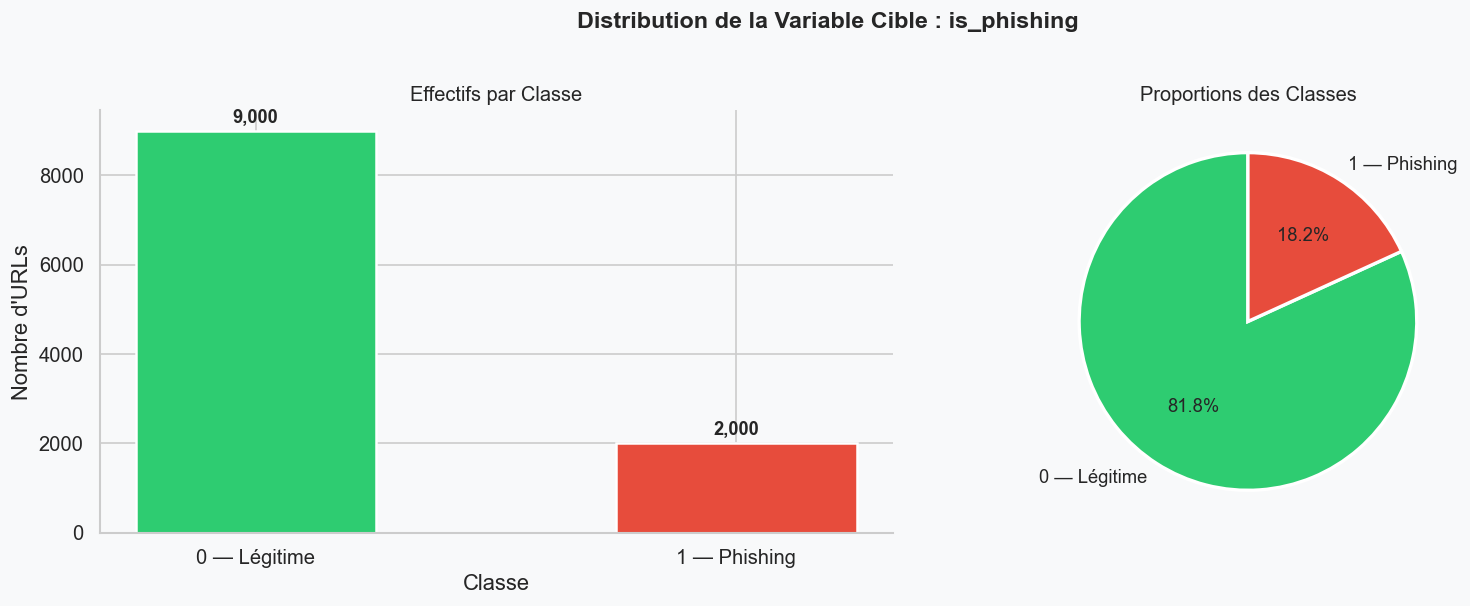


 Graphique sauvegardé : data/class_distribution.png


In [22]:
# ─── Barplot de distribution des classes ─────────────────────────────────────
COLORS = {'Légitime': '#2ecc71', 'Phishing': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution de la Variable Cible : is_phishing', fontsize=14, fontweight='bold', y=1.01)

labels = ['0 — Légitime', '1 — Phishing']
values = [counts.get(0, 0), counts.get(1, 0)]
bar_colors = [COLORS['Légitime'], COLORS['Phishing']]

# --- Graphique 1 : Barplot (effectifs) ---
bars = axes[0].bar(labels, values, color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Effectifs par Classe', fontsize=12)
axes[0].set_ylabel("Nombre d'URLs")
axes[0].set_xlabel("Classe")
for bar, val in zip(bars, values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.01,
        f'{val:,}',
        ha='center', va='bottom', fontweight='bold', fontsize=11
    )
axes[0].set_facecolor('#f8f9fa')
axes[0].spines[['top', 'right']].set_visible(False)

# --- Graphique 2 : Pie chart (proportions) ---
wedge_props = {'linewidth': 2, 'edgecolor': 'white'}
axes[1].pie(
    values,
    labels=labels,
    colors=bar_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=wedge_props,
    textprops={'fontsize': 11}
)
axes[1].set_title('Proportions des Classes', fontsize=12)

plt.tight_layout()
plt.savefig('../figures/class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('\n Graphique sauvegardé : data/class_distribution.png')

---
## 3 — Qualité des Données : Valeurs Manquantes, Types et Statistiques

In [23]:
# ─── Vérification des valeurs manquantes (NaN) ───────────────────────────────
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Feature': df.columns,
    'Nb NaN': missing.values,
    'Taux NaN (%)': missing_pct.values,
    'Type': df.dtypes.values
})

print('les Valeurs manquantes (NaN) par feature ')
display(missing_df)

total_nan = missing.sum()
if total_nan == 0:
    print('\n Aucune valeur NaN détectée dans le dataset.')
else:
    print(f'\n {total_nan} valeurs NaN détectées — vérification requise.')

les Valeurs manquantes (NaN) par feature 


,Feature,Nb NaN,Taux NaN (%),Type
0,url,0,0.0,str
1,is_phishing,0,0.0,int64
2,url_length,0,0.0,int64
3,domain_length,0,0.0,int64
4,num_dots,0,0.0,int64
5,num_subdomains,0,0.0,int64
6,num_hyphens,0,0.0,int64
7,num_underscores,0,0.0,int64
8,num_at_signs,0,0.0,int64
9,has_port,0,0.0,int64



 Aucune valeur NaN détectée dans le dataset.


In [24]:
# ─── Vérification de domain_age_days = -1 (valeur sentinelle) ────────────────
if 'domain_age_days' in df.columns:
    sentinel_count = (df['domain_age_days'] == -1).sum()
    sentinel_pct = sentinel_count / len(df) * 100
    print(f' domain_age_days = -1 (WHOIS indisponible) : {sentinel_count:,} lignes ({sentinel_pct:.1f}%)')
    print('   → Ce n\'est pas un NaN, c\'est une valeur sentinelle intentionnelle (voir DATASET.md 3.2)')

 domain_age_days = -1 (WHOIS indisponible) : 1,744 lignes (15.9%)
   → Ce n'est pas un NaN, c'est une valeur sentinelle intentionnelle (voir DATASET.md 3.2)


In [25]:
# ─── Types de données ─────────────────────────────────────────────────────────
print(' Types de données (dtypes) ')
dtype_summary = df.dtypes.reset_index()
dtype_summary.columns = ['Feature', 'Type']
display(dtype_summary)

print(f'\nRécapitulatif :')
for dtype, count in df.dtypes.value_counts().items():
    print(f'  {dtype} → {count} feature(s)')

 Types de données (dtypes) 


,Feature,Type
0,url,str
1,is_phishing,int64
2,url_length,int64
3,domain_length,int64
4,num_dots,int64
5,num_subdomains,int64
6,num_hyphens,int64
7,num_underscores,int64
8,num_at_signs,int64
9,has_port,int64



Récapitulatif :
  int64 → 14 feature(s)
  str → 2 feature(s)
  float64 → 1 feature(s)


In [26]:
# ─── Statistiques descriptives par classe ─────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.drop('is_phishing').tolist()

print('Statistiques descriptives par classe (is_phishing) ')
stats_by_class = df.groupby('is_phishing')[num_cols].mean().round(2)
stats_by_class.index = ['0 — Légitime', '1 — Phishing']
display(stats_by_class.T.rename(columns=str))

Statistiques descriptives par classe (is_phishing) 


,0 — Légitime,1 — Phishing
url_length,19.82,49.96
domain_length,11.82,25.41
num_dots,1.10,1.99
num_subdomains,0.10,0.84
num_hyphens,0.05,1.28
num_underscores,0.00,0.07
num_at_signs,0.00,0.00
has_port,0.00,0.00
has_https,1.00,0.86
has_http_in_domain,0.00,0.00


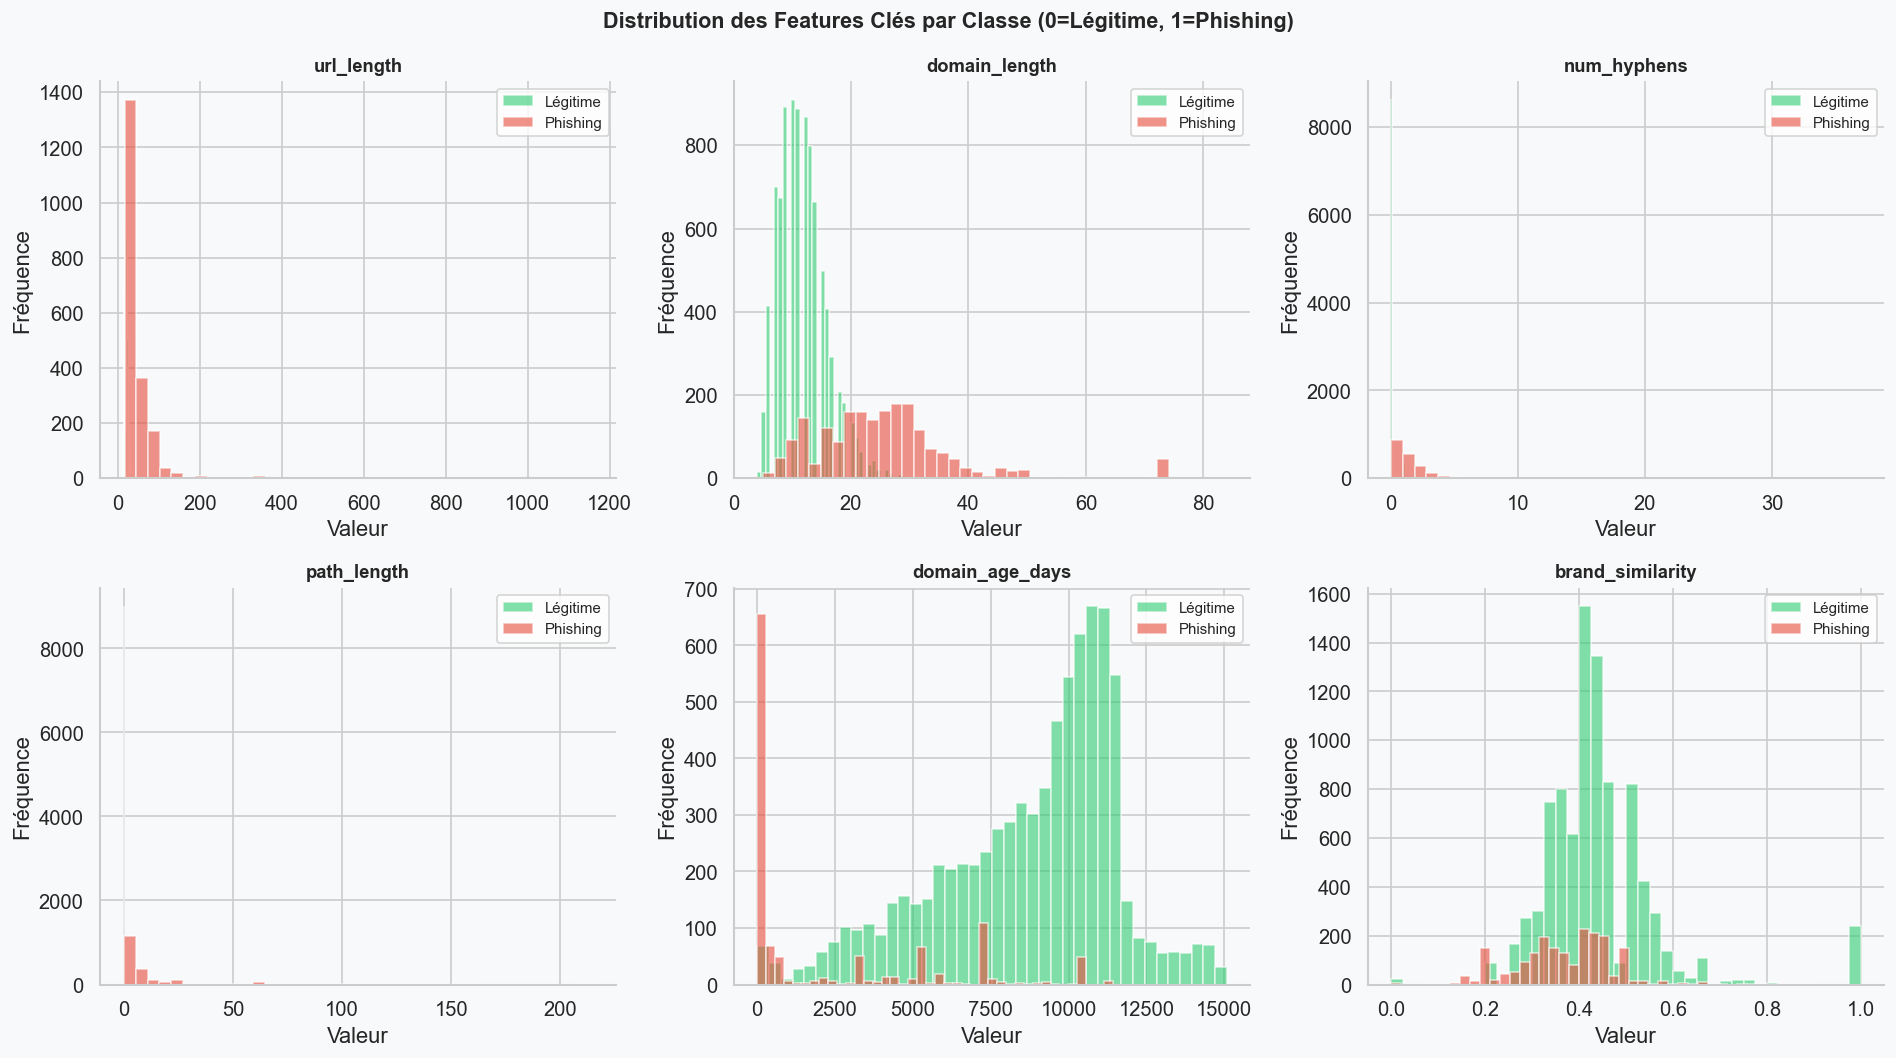

 Graphique sauvegardé : data/feature_distributions.png


In [27]:
# ─── Distribution des features numériques clés par classe ────────────────────
key_features = ['url_length', 'domain_length', 'num_hyphens', 'path_length', 'domain_age_days', 'brand_similarity']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribution des Features Clés par Classe (0=Légitime, 1=Phishing)', fontsize=13, fontweight='bold')
axes = axes.flatten()

palette = {0: '#2ecc71', 1: '#e74c3c'}

for i, feat in enumerate(key_features):
    ax = axes[i]
    for label, color in palette.items():
        data = df[df['is_phishing'] == label][feat]
        # Filtrer les valeurs sentinelles -1 pour domain_age_days
        if feat == 'domain_age_days':
            data = data[data >= 0]
        ax.hist(data, bins=40, alpha=0.6, color=color, label=f"{'Légitime' if label == 0 else 'Phishing'}")
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('../figures/feature_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Graphique sauvegardé : data/feature_distributions.png')

---
## 4 — Synthèse et Validation du Cahier des Charges

### 4.1 Validation des Critères Obligatoires
La cellule ci-dessous vérifie automatiquement que le dataset respecte les 4 critères imposés.

In [28]:
print('=== Validation du Dataset ===')
print(f"1. Lignes >= 10 000 : {'OK' if len(df) >= 10000 else 'KO'} ({len(df)} lignes)")
print(f"2. Features >= 8 : {'OK' if len(df.columns)-2 >= 8 else 'KO'} ({len(df.columns)-2} features)")
print(f"3. Zéro NaN : {'OK' if df.isna().sum().sum() == 0 else 'KO'} ({df.isna().sum().sum()} NaN)")
minority_pct = df['is_phishing'].mean() * 100
print(f"4. Classe minoritaire dans [5%, 25%] : {'OK' if 5 <= minority_pct <= 25 else 'KO'} ({minority_pct:.2f}%)")

=== Validation du Dataset ===
1. Lignes >= 10 000 : OK (11000 lignes)
2. Features >= 8 : OK (15 features)
3. Zéro NaN : OK (0 NaN)
4. Classe minoritaire dans [5%, 25%] : OK (18.18%)


## 4 — Conclusion

| Critère | Valeur | Statut |
|---|---|---|
| Lignes totales | 11 000 | OK ≥ 10 000 |
| Nombre de features | 15 | OK ≥ 8 |
| Valeurs manquantes | 0 | OK |
| Classe minoritaire | 18 % | OK dans [5 %, 25 %] |

OK Dataset exploitable pour la Phase 2.